In [1]:
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb


## Load data

In [2]:
train_df = pd.read_parquet("train.parquet")
val_df   = pd.read_parquet("val.parquet")
test_df  = pd.read_parquet("test.parquet")

print(
    f"Train rows: {len(train_df)} | "
    f"Val rows: {len(val_df)} | "
    f"Test rows: {len(test_df)}"
)


Train rows: 52259860 | Val rows: 853720 | Test rows: 853720


## Feature lists

In [3]:
FEATURES = [
    "sell_price", "wm_yr_wk", "month", "year",
    "snap_CA", "snap_TX", "snap_WI",
    "dow", "weekofyear",
    "lag_7", "lag_14", "lag_28",
    "rmean_7", "rmean_14", "rmean_28",

    # categorical columns MUST be in FEATURES
    "item_id", "dept_id", "cat_id", "store_id", "state_id"
]

CAT_FEATURES = [
    "item_id", "dept_id", "cat_id", "store_id", "state_id"
]


## Prepare LightGBM data

In [4]:
def prepare_lgb_data(df, features):
    X = df[features]
    y = df["sales"].values.astype(np.float32)
    return X, y


## Evaluation function

In [5]:
def evaluate(y_true, y_pred, name):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    denom = np.maximum(y_true, 1.0)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100

    print(f"\n{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAPE : {mape:.2f}%")

    return mae, rmse, mape


## WRMSSE computation

In [6]:
def compute_wrmsse(train_df, eval_df, pred_col,
                   target_col="sales", id_col="id"):

    weights = train_df.groupby(id_col)[target_col].sum()
    weights = weights / weights.sum()

    scale = train_df.groupby(id_col)[target_col].apply(
        lambda x: np.mean(np.diff(x.values) ** 2) if len(x) > 1 else np.nan
    )

    rmsse_vals = {}

    for sid, g in eval_df.groupby(id_col):
        s = scale.get(sid, np.nan)
        if not np.isfinite(s) or s == 0:
            continue

        mse = np.mean((g[target_col].values - g[pred_col].values) ** 2)
        rmsse_vals[sid] = np.sqrt(mse / s)

    rmsse_vals = pd.Series(rmsse_vals)
    weights = weights.reindex(rmsse_vals.index).fillna(0.0)

    return float((weights * rmsse_vals).sum())


## Unified evaluation

In [7]:
def evaluate_with_wrmsse(train_df, eval_df, y_true, y_pred, pred_col, name):
    mae, rmse, mape = evaluate(y_true, y_pred, name)

    eval_df = eval_df.copy()
    eval_df[pred_col] = y_pred

    wrmsse = compute_wrmsse(train_df, eval_df, pred_col)
    print(f"WRMSSE: {wrmsse:.4f}")

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "WRMSSE": wrmsse
    }


## Prepare train & validation sets

In [8]:
X_train, y_train = prepare_lgb_data(train_df, FEATURES)
X_val, y_val     = prepare_lgb_data(val_df, FEATURES)


## Convert categorical feature names

In [9]:
CAT_FEATURES_IDX = [
    X_train.columns.get_loc(col)
    for col in CAT_FEATURES
]


## Build LightGBM datasets

In [10]:
lgb_train = lgb.Dataset(
    X_train, y_train,
    categorical_feature=CAT_FEATURES_IDX,
    free_raw_data=False
)

lgb_val = lgb.Dataset(
    X_val, y_val,
    categorical_feature=CAT_FEATURES_IDX,
    reference=lgb_train,
    free_raw_data=False
)


## LightGBM parameters

In [11]:
lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbosity": -1,
    "seed": 42
}


## Train LightGBM model

In [12]:
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=3000,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=200)
    ]
)


Training until validation scores don't improve for 100 rounds
[200]	valid_0's rmse: 2.02599
[400]	valid_0's rmse: 2.01404
[600]	valid_0's rmse: 2.00696
[800]	valid_0's rmse: 2.00338
[1000]	valid_0's rmse: 1.99991
[1200]	valid_0's rmse: 1.99718
[1400]	valid_0's rmse: 1.99441
Early stopping, best iteration is:
[1480]	valid_0's rmse: 1.99398


## Validation evaluation

In [13]:
val_pred = lgb_model.predict(
    X_val,
    num_iteration=lgb_model.best_iteration
)

lgb_val_results = evaluate_with_wrmsse(
    train_df=train_df,
    eval_df=val_df,
    y_true=y_val,
    y_pred=val_pred,
    pred_col="lgb_pred",
    name="LightGBM (Validation)"
)



LightGBM (Validation)
MAE  : 0.9008
RMSE : 1.9940
MAPE : 53.28%
WRMSSE: 0.6870


## Test evaluation

In [14]:
X_test, y_test = prepare_lgb_data(test_df, FEATURES)

test_pred = lgb_model.predict(
    X_test,
    num_iteration=lgb_model.best_iteration
)

lgb_test_results = evaluate_with_wrmsse(
    train_df=train_df,
    eval_df=test_df,
    y_true=y_test,
    y_pred=test_pred,
    pred_col="lgb_pred",
    name="LightGBM (Test)"
)



LightGBM (Test)
MAE  : 0.9281
RMSE : 2.1868
MAPE : 53.95%
WRMSSE: 0.7398


## Final results

In [15]:
final_lgb_results = pd.DataFrame([
    lgb_val_results,
    lgb_test_results
])

final_lgb_results


,Model,MAE,RMSE,MAPE,WRMSSE
0,LightGBM (Validation),0.900831,1.993981,53.278202,0.686980
1,LightGBM (Test),0.928104,2.186830,53.950161,0.739754


## Prepare validation dataframe

In [16]:
lgb_val_plot_df = val_df.copy()
lgb_val_plot_df["lgb_pred"] = val_pred


## Actual vs prediction

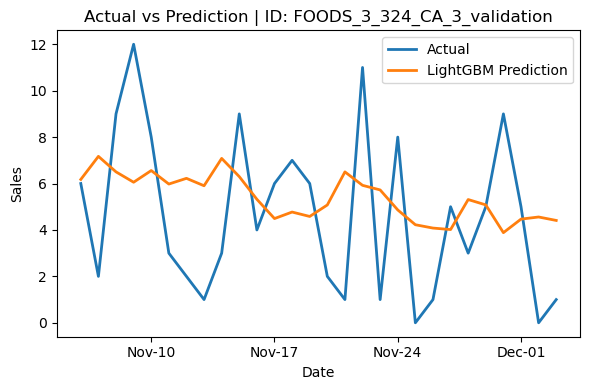

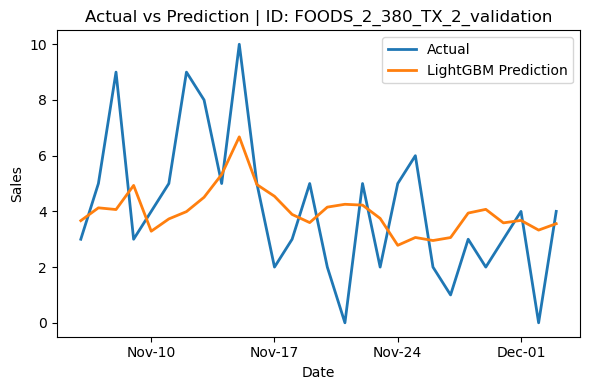

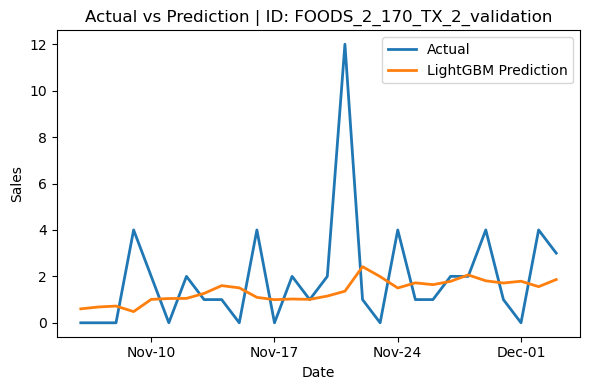

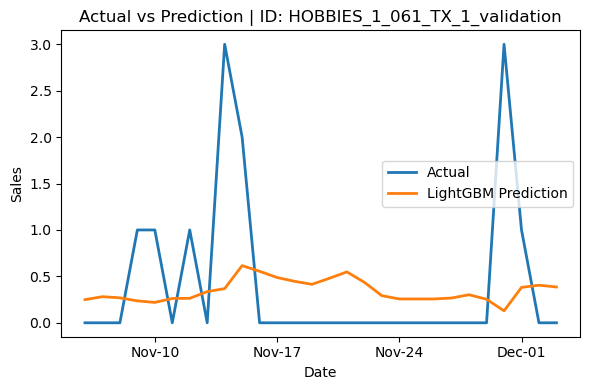

In [17]:
valid_ids = (
    lgb_val_plot_df.groupby("id")["sales"]
    .sum()
    .loc[lambda x: x > 0]
    .index
)

np.random.seed(42)
selected_ids = np.random.choice(valid_ids, size=4, replace=False)


def plot_actual_vs_pred(series_id):
    df_plot = lgb_val_plot_df[lgb_val_plot_df["id"] == series_id]

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(df_plot["date"], df_plot["sales"], label="Actual", linewidth=2)
    ax.plot(df_plot["date"], df_plot["lgb_pred"], label="LightGBM Prediction", linewidth=2)

    ax.set_title(f"Actual vs Prediction | ID: {series_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")
    ax.legend()

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))

    plt.tight_layout()
    plt.show()

for sid in selected_ids:
    plot_actual_vs_pred(sid)

## Average residual over time

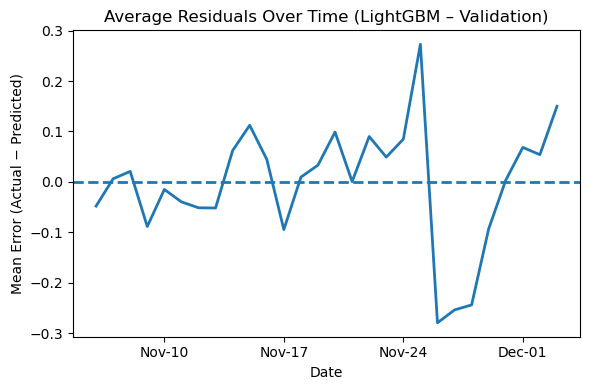

In [18]:
lgb_val_plot_df["residual"] = (
    lgb_val_plot_df["sales"] - lgb_val_plot_df["lgb_pred"]
)

daily_residuals = (
    lgb_val_plot_df.groupby("date")["residual"].mean()
)

plt.figure(figsize=(6, 4))
plt.plot(daily_residuals.index, daily_residuals.values, linewidth=2)
plt.axhline(0, linestyle="--", linewidth=2)

plt.title("Average Residuals Over Time (LightGBM – Validation)")
plt.xlabel("Date")
plt.ylabel("Mean Error (Actual − Predicted)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))

plt.tight_layout()
plt.show()


## Residual distribution

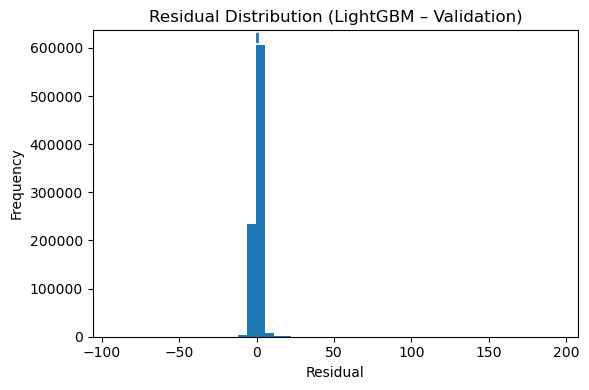

In [19]:
plt.figure(figsize=(6, 4))
plt.hist(lgb_val_plot_df["residual"], bins=50)
plt.axvline(0, linestyle="--", linewidth=2)

plt.title("Residual Distribution (LightGBM – Validation)")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## FINAL 28-DAY FORECASTING & SUBMISSION CODE

## Load sample submission file

In [20]:
sample_sub = pd.read_csv("sample_submission.csv")


## Prepare last known history

In [21]:
# Use ONLY test_df (latest available data)
history_df = (
    test_df
    .sort_values(["id", "date"])
    .groupby("id", group_keys=False)
    .tail(28)          # only what we need
    .reset_index(drop=True)
)


## Recursive forecasting

In [22]:
def recursive_forecast_lgbm(
    history_df,
    model,
    features,
    horizon=28
):
    """
    Memory-safe, aligned recursive forecasting for LightGBM
    """

    # Keep only required columns
    df = history_df[["id", "date", "sales"]].copy()

    future_results = []

    for h in range(1, horizon + 1):

        # ---- For each id, keep last 28 rows only ----
        window_df = (
            df
            .sort_values(["id", "date"])
            .groupby("id", group_keys=False)
            .tail(28)
        )

        last_date = window_df["date"].max()
        future_date = last_date + pd.Timedelta(days=1)

        # ---- Compute lag features (1 row per id) ----
        lag_features = (
            window_df
            .groupby("id")["sales"]
            .agg(
                lag_7=lambda x: x.iloc[-7] if len(x) >= 7 else 0.0,
                lag_14=lambda x: x.iloc[-14] if len(x) >= 14 else 0.0,
                lag_28=lambda x: x.iloc[-28] if len(x) >= 28 else 0.0,
                rmean_7=lambda x: x.tail(7).mean(),
                rmean_14=lambda x: x.tail(14).mean(),
                rmean_28=lambda x: x.tail(28).mean(),
            )
            .reset_index()
        )

        # ---- Date features (same for all ids) ----
        lag_features["date"] = future_date
        lag_features["dow"] = future_date.weekday()
        lag_features["weekofyear"] = int(future_date.isocalendar().week)
        lag_features["month"] = future_date.month
        lag_features["year"] = future_date.year

        # ---- Bring static / categorical features ----
        static_cols = [
            c for c in features
            if c not in lag_features.columns and c != "sales"
        ]

        static_df = (
            history_df
            .drop_duplicates("id")[["id"] + static_cols]
        )

        future_df = lag_features.merge(
            static_df,
            on="id",
            how="left"
        )

        # ---- Predict ----
        X_future = future_df[features]

        preds = model.predict(
            X_future,
            num_iteration=model.best_iteration
        )

        preds = np.maximum(preds, 0)  # no negative sales

        future_df["sales"] = preds

        future_results.append(
            future_df[["id", "date", "sales"]]
        )

        # ---- Append predictions back for next step ----
        df = pd.concat(
            [df, future_df[["id", "date", "sales"]]],
            ignore_index=True
        )

    return pd.concat(future_results, ignore_index=True)


## Generate 28 days forecasts

In [23]:
future_forecasts = recursive_forecast_lgbm(
    history_df=history_df,
    model=lgb_model,
    features=FEATURES,
    horizon=28
)


## Convert to submission format

In [24]:
submission = (
    future_forecasts
    .assign(day=lambda x: x.groupby("id").cumcount() + 1)
    .pivot(index="id", columns="day", values="sales")
    .reset_index()
)

submission.columns = ["id"] + [f"F{i}" for i in range(1, 29)]


## Align with sample submission

In [25]:
submission = sample_sub[["id"]].merge(
    submission,
    on="id",
    how="left"
)

submission.fillna(0, inplace=True)


In [26]:
# Round sales to nearest integer and ensure non-negative
submission.iloc[:, 1:] = (
    submission.iloc[:, 1:]
    .round(0)
    .clip(lower=0)
    .astype(int)
)


## Save final submission file

In [27]:
submission.to_csv("final_submission.csv", index=False)


In [28]:
# Convert submission back to long format
future_long = (
    submission
    .melt(id_vars="id", var_name="day", value_name="sales")
)

# Convert F1..F28 → integer day offset
future_long["day"] = future_long["day"].str.replace("F", "").astype(int)

# Get forecast start date (day after last history date)
forecast_start = history_df["date"].max() + pd.Timedelta(days=1)

future_long["date"] = forecast_start + pd.to_timedelta(future_long["day"] - 1, unit="D")

future_long = future_long[["id", "date", "sales"]]


## Basic sanity checks

In [29]:
print("Sales dtype:", future_long["sales"].dtype)
print("Any NaNs:", future_long["sales"].isna().any())
print("Any negatives:", (future_long["sales"] < 0).any())


Sales dtype: float64
Any NaNs: False
Any negatives: False


In [30]:
future_long["sales"].describe()


count    853720.000000
mean          1.163049
std           2.582461
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max         139.000000
Name: sales, dtype: float64

## Plot last 28 actuals vs next 28 rounded forecasts

In [34]:
np.random.seed(2)

sample_ids = np.random.choice(
    future_long["id"].unique(),
    size=4,
    replace=False
)

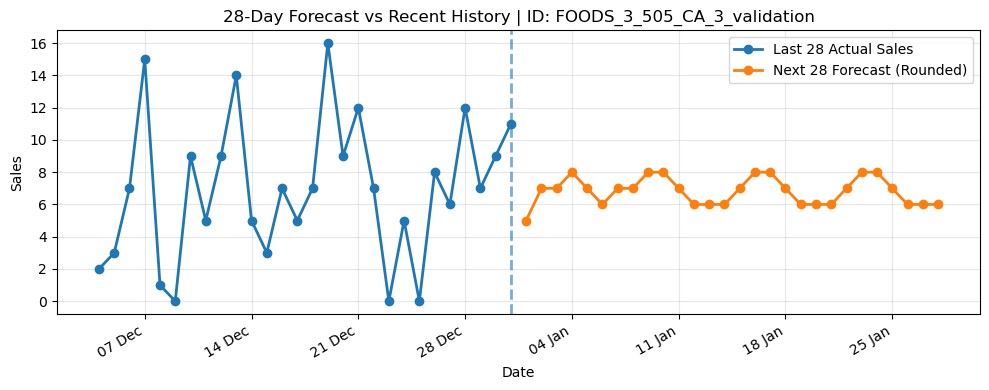

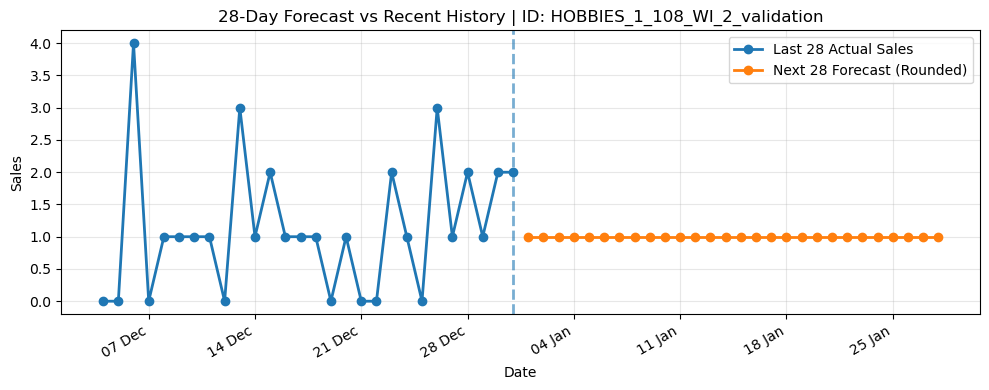

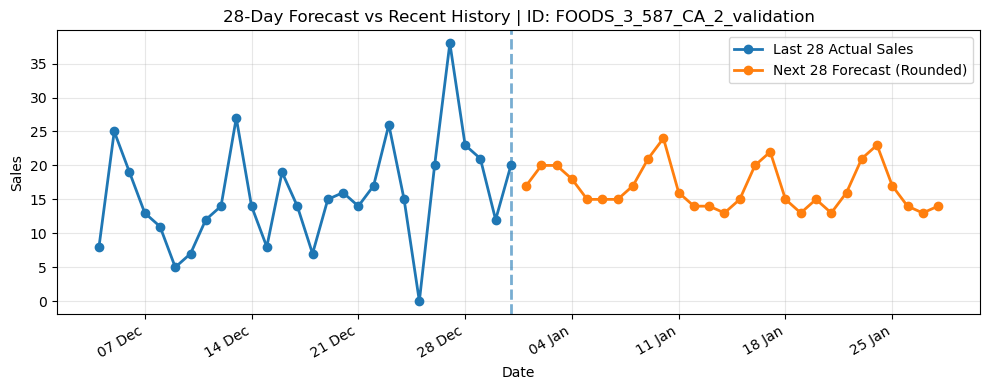

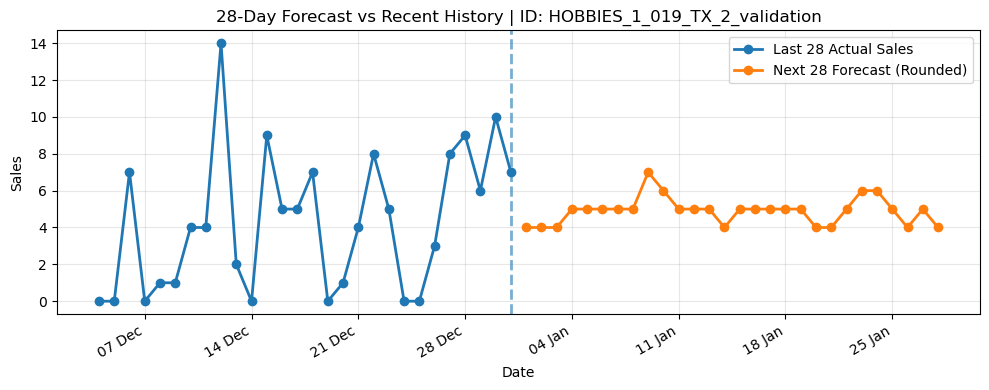

In [35]:
for sid in sample_ids:
    hist = history_df[history_df["id"] == sid]
    fut  = future_long[future_long["id"] == sid]

    fig, ax = plt.subplots(figsize=(10, 4))

    # Plot history
    ax.plot(
        hist["date"],
        hist["sales"],
        label="Last 28 Actual Sales",
        linewidth=2,
        marker="o"
    )

    # Plot forecast
    ax.plot(
        fut["date"],
        fut["sales"],
        label="Next 28 Forecast (Rounded)",
        linewidth=2,
        marker="o"
    )

    # Vertical line separating history & forecast
    split_date = hist["date"].max()
    ax.axvline(split_date, linestyle="--", linewidth=2, alpha=0.6)

    # Titles & labels
    ax.set_title(f"28-Day Forecast vs Recent History | ID: {sid}", fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")

    # ---- FORCE CLEAN DATE TICKS ----
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

    # Rotate labels slightly
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    # Grid & legend
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

## Total forecasted sales per day

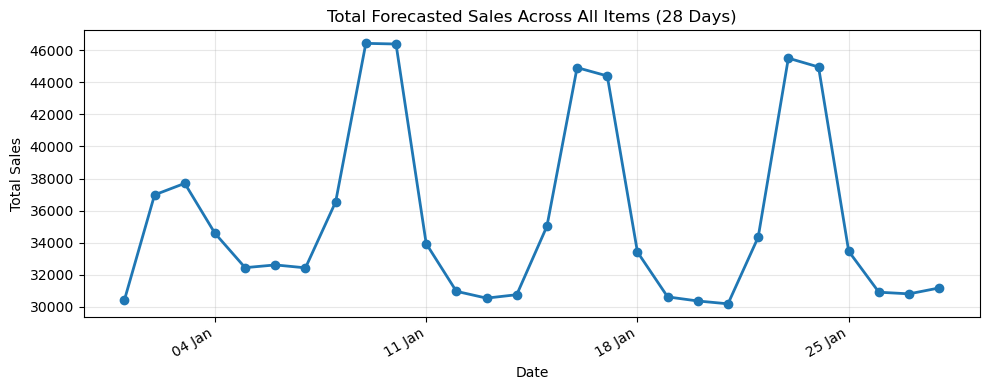

In [33]:
daily_total = (
    future_long
    .groupby("date")["sales"]
    .sum()
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    daily_total.index,
    daily_total.values,
    linewidth=2,
    marker="o"
)

# Title & labels
ax.set_title("Total Forecasted Sales Across All Items (28 Days)", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales")

# ---- FIX DATE FORMATTING ----
ax.xaxis.set_major_locator(
    mdates.WeekdayLocator(byweekday=mdates.MO, interval=1)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)

# Rotate labels slightly for clarity
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# Grid for readability
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()